In [6]:
readme = """# Indian MSME Credit Risk Framework
## An Integrated Scorecard, Stress Testing, and Shadow Rating Project

**Author:** Priti Dutta
**Tools:** Python, Google Colab, scorecardpy, scikit-learn, pandas
**Dataset:** UCI Default of Credit Card Clients (30,000 borrowers)

---

## Project Overview

This project builds an end-to-end credit risk framework for a fictional
Indian NBFC (Pradhan MSME Lending Institution) across three interconnected
notebooks. Each notebook is a standalone deliverable that feeds into the next,
demonstrating systems-level thinking across credit risk, model risk, and
credit research functions.

---

## Notebooks

### 01_Scorecard
Builds a credit scorecard using Weight of Evidence (WoE), Information Value (IV),
and logistic regression on 30,000 borrower records. Scores the portfolio and
classifies borrowers into Low, Medium, and High Risk bands.

- AUC-ROC: 0.76
- Score separation: 80 points (Non-default: 420.7 | Default: 340.6)
- High Risk default rate: 47.10% | Low Risk: 7.88%

### 02_Stress_Testing
Engineers synthetic Indian MSME features (sector, region, GST compliance,
macro indicators) onto the scored portfolio and runs three RBI-style macro
stress scenarios using an IFRS 9-aligned PD x LGD x EAD framework.

| Scenario | GDP Growth | Repo Rate | Portfolio ECL Rate |
|----------|-----------|-----------|-------------------|
| Base | 6.5% | 6.5% | 8.00% |
| Moderate Stress | 4.0% | 7.5% | 11.21% |
| Severe Stress | 1.5% | 9.0% | 16.01% |

### 03_Shadow_Rating
Aggregates stress test results into a CRISIL-style shadow credit rating
using a five-dimension weighted scorecard. Produces a formal rating rationale
document with upward and downward rating sensitivities.

**Final Rating: BB — Moderate Risk (Weighted Score: 2.75/5.00)**

---

## Key findings

- Portfolio ECL doubles from base to severe stress, indicating meaningful
  macro sensitivity
- High Risk segment PD approaches 94% under severe stress — primary source
  of tail risk
- GST non-compliance concentrated in High Risk borrowers (60%) signals
  informal operations as a leading default indicator
- BB rating constrained by asset quality and stress resilience; adequate
  diversification prevents a lower rating

---

## Project Structure
Credit_Risk_Framework/
├── Data/
│   └── default of credit card clients.xls
├── notebooks/
│   ├── 01_Scorecard.ipynb
│   ├── 02_Stress_Testing.ipynb
│   └── 03_Shadow_Rating.ipynb
└── Outputs/
├── scored_portfolio.csv
├── stress_results.csv
├── enriched_portfolio.csv
└── shadow_rating_report.txt

---

## Limitations and Future Work
- Synthetic MSME features are illustrative; real deployment would require
  RBI/SIDBI borrower-level data
- LGD assumed constant at 45%; a dynamic LGD model would strengthen Part 2
- Shadow rating framework would benefit from calibration against actual
  CRISIL/ICRA rating outcomes
"""

with open('/content/drive/MyDrive/Credit_Risk_Framework/README.md', 'w') as f:
    f.write(readme)

print("README saved.")

README saved.


# Notebook 1: Credit Scorecard Development
## Indian MSME Credit Risk Framework
### Dataset: UCI Default of Credit Card Clients
### Model: Logistic Regression with WoE/IV Feature Transformation

**Objective:** Build a credit scorecard that assigns risk scores to borrowers
and classifies them into Low, Medium, and High risk bands.

**Key Results:**
- AUC-ROC: 0.76
- Score separation: 80 points (Non-default: 420.7 | Default: 340.6)
- High Risk default rate: 47% | Low Risk default rate: 8%

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd

# Load dataset
df = pd.read_excel('/content/drive/MyDrive/Credit_Risk_Framework/Data/default of credit card clients.xls',
                   header=1)

# First look
print(df.shape)
print(df.columns.tolist())

(30000, 25)
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [9]:
# Rename target column for ease
df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)

# Check nulls and data types
print(df.isnull().sum())
print("\n")
print(df.dtypes)
print("\n")

# Check target distribution
print(df['DEFAULT'].value_counts())
print(f"\nDefault rate: {df['DEFAULT'].mean()*100:.2f}%")

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64


ID           int64
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
DEFAULT      int64
dtype: object


DEFAULT
0    23364
1     6636
Name: count, dtype: int64

Default rate: 22.12%


In [10]:
# Check unique values in categorical columns
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(f"{col}: {sorted(df[col].unique())}")

SEX: [np.int64(1), np.int64(2)]
EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [11]:
# Clean EDUCATION — group 0, 5, 6 into 'Other' (represented as 4)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# Clean MARRIAGE — group 0 into 'Other' (represented as 3)
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

# Verify
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(f"{col}: {sorted(df[col].unique())}")

SEX: [np.int64(1), np.int64(2)]
EDUCATION: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE: [np.int64(1), np.int64(2), np.int64(3)]


In [12]:
# Feature Engineering

# 1. Utilisation ratio — how much of the credit limit is being used
df['UTIL_RATIO'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

# 2. Payment ratio — how much of the bill is actually being paid
df['PAY_RATIO'] = df['PAY_AMT1'] / (df['BILL_AMT1'] + 1)

# 3. Average bill over 6 months
df['AVG_BILL'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                      'BILL_AMT4','BILL_AMT5','BILL_AMT6']].mean(axis=1)

# 4. Average payment over 6 months
df['AVG_PAY'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                     'PAY_AMT4','PAY_AMT5','PAY_AMT6']].mean(axis=1)

# 5. Max repayment delay across 6 months
df['MAX_DELAY'] = df[['PAY_0','PAY_2','PAY_3',
                       'PAY_4','PAY_5','PAY_6']].max(axis=1)

# Verify
print(df[['UTIL_RATIO','PAY_RATIO','AVG_BILL','AVG_PAY','MAX_DELAY']].describe())

         UTIL_RATIO     PAY_RATIO       AVG_BILL        AVG_PAY     MAX_DELAY
count  30000.000000  2.999200e+04   30000.000000   30000.000000  30000.000000
mean       0.423764           inf   44976.945200    5275.232094      0.438733
std        0.411454           NaN   63260.721860   10137.946323      1.345154
min       -0.619890 -1.088325e+04  -56043.166667       0.000000     -2.000000
25%        0.022031  3.437551e-02    4781.333333    1113.291667      0.000000
50%        0.313991  5.558873e-02   21051.833333    2397.166667      0.000000
75%        0.829821  2.637039e-01   57104.416667    5583.916667      2.000000
max        6.454977           inf  877313.833333  627344.333333      8.000000


In [13]:
import numpy as np

# Fix PAY_RATIO — cap at 99th percentile to remove inf/extreme values
df['PAY_RATIO'] = df['PAY_AMT1'] / (df['BILL_AMT1'].abs() + 1)
cap = df['PAY_RATIO'].quantile(0.99)
df['PAY_RATIO'] = df['PAY_RATIO'].clip(upper=cap)

# Fix UTIL_RATIO — clip to 0 minimum (negative utilisation not meaningful)
df['UTIL_RATIO'] = df['UTIL_RATIO'].clip(lower=0)

# Verify no more inf or nan
print(df[['UTIL_RATIO','PAY_RATIO','AVG_BILL','AVG_PAY','MAX_DELAY']].describe())
print("\nAny inf values:", np.isinf(df[['UTIL_RATIO','PAY_RATIO']]).sum().sum())
print("Any null values:", df[['UTIL_RATIO','PAY_RATIO']].isnull().sum().sum())

         UTIL_RATIO     PAY_RATIO       AVG_BILL        AVG_PAY     MAX_DELAY
count  30000.000000  30000.000000   30000.000000   30000.000000  30000.000000
mean       0.423930     18.125244   44976.945200    5275.232094      0.438733
std        0.411243    127.936415   63260.721860   10137.946323      1.345154
min        0.000000      0.000000  -56043.166667       0.000000     -2.000000
25%        0.022031      0.035244    4781.333333    1113.291667      0.000000
50%        0.313991      0.057385   21051.833333    2397.166667      0.000000
75%        0.829821      0.294092   57104.416667    5583.916667      2.000000
max        6.454977   1133.862500  877313.833333  627344.333333      8.000000

Any inf values: 0
Any null values: 0


In [14]:
from sklearn.model_selection import train_test_split

# Define features
features = [
    'LIMIT_BAL', 'AGE', 'SEX', 'EDUCATION', 'MARRIAGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'UTIL_RATIO', 'PAY_RATIO', 'AVG_BILL', 'AVG_PAY', 'MAX_DELAY'
]

X = df[features]
y = df['DEFAULT']

# Train/test split — 80/20, stratified to preserve default rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate: {y_test.mean()*100:.2f}%")

Train size: (24000, 16)
Test size: (6000, 16)
Train default rate: 22.12%
Test default rate: 22.12%


In [15]:
!pip install scorecardpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


[INFO] creating woe binning ...


/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

Binning on 30000 rows and 17 columns in 00:00:21
       Feature        IV
0        PAY_0  0.869381
1    MAX_DELAY  0.742568
2        PAY_2  0.546857
3        PAY_3  0.410070
4        PAY_4  0.355530
5        PAY_5  0.329437
6        PAY_6  0.283079
7      AVG_PAY  0.179712
8    LIMIT_BAL  0.168281
9    PAY_RATIO  0.151202
10  UTIL_RATIO  0.053422
11         AGE  0.021694
12   EDUCATION  0.015683
13    AVG_BILL  0.010792
14         SEX  0.009180
15    MARRIAGE  0.005132


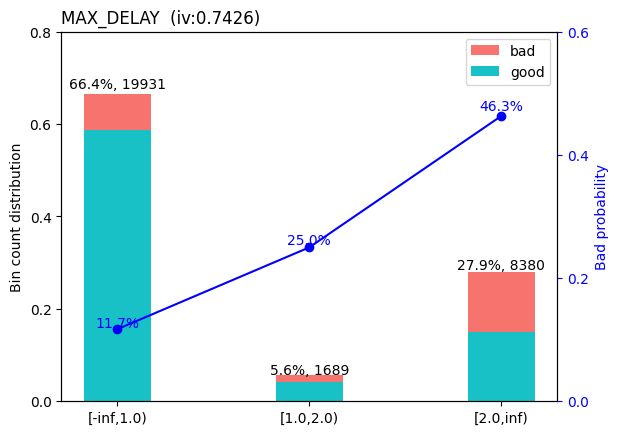

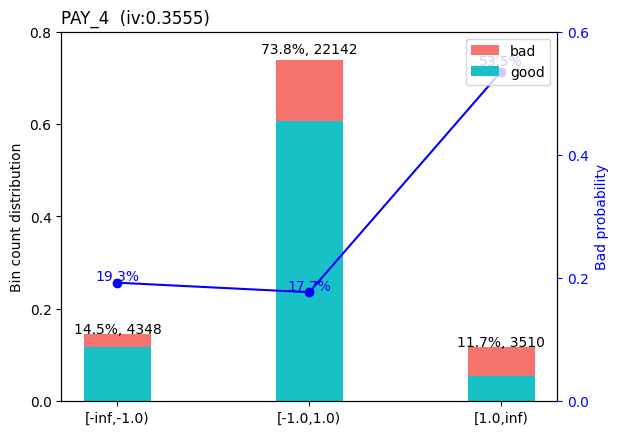

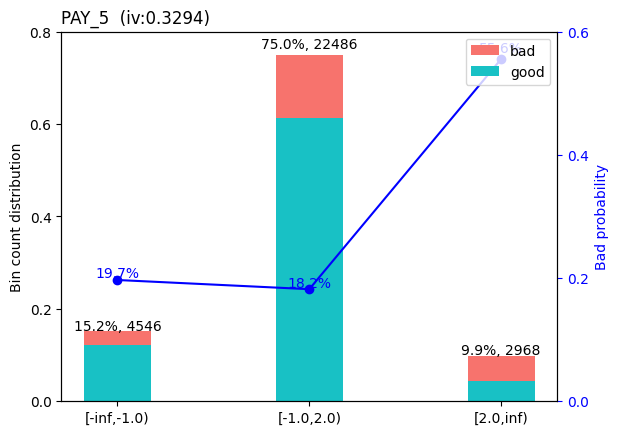

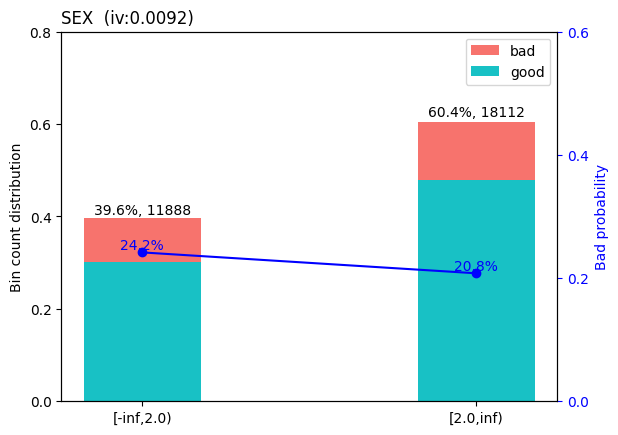

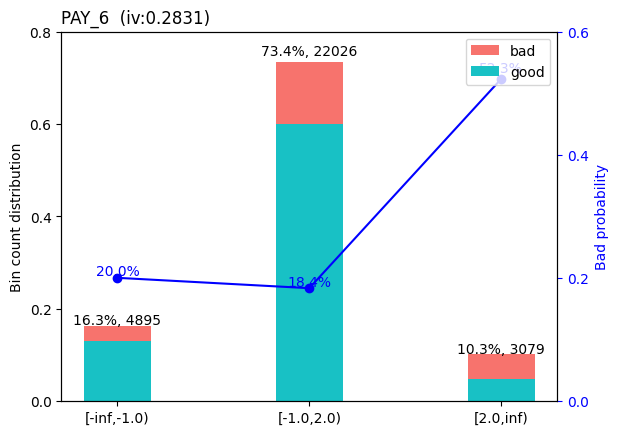

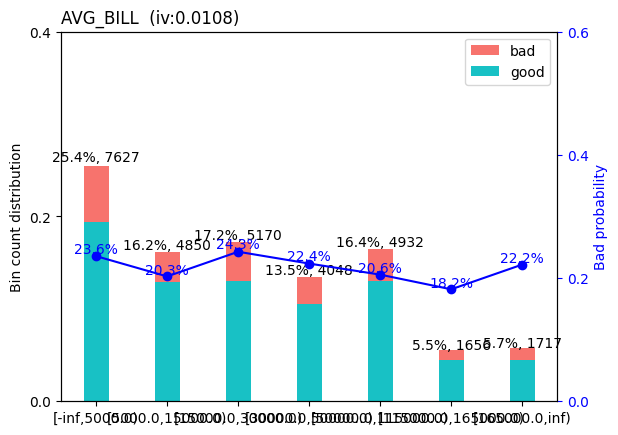

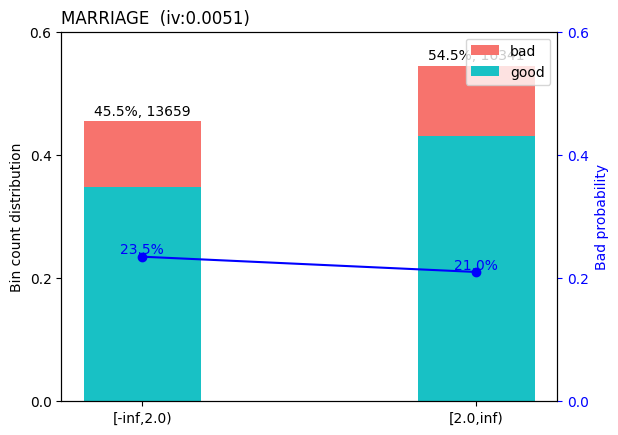

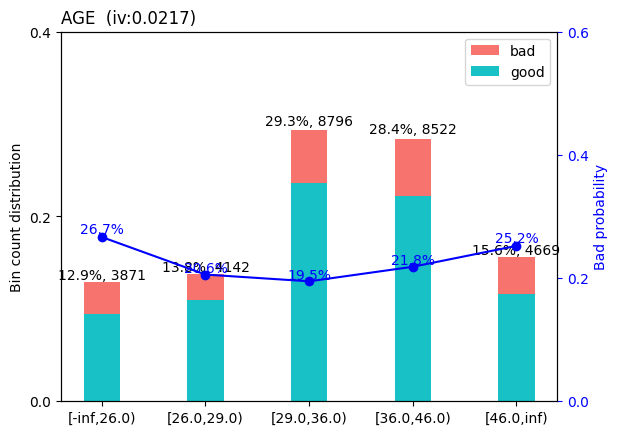

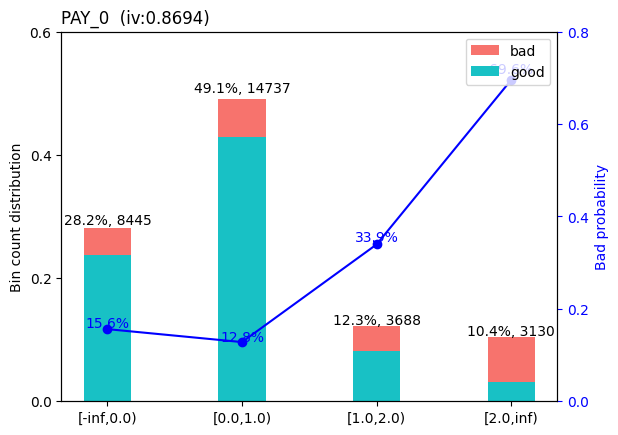

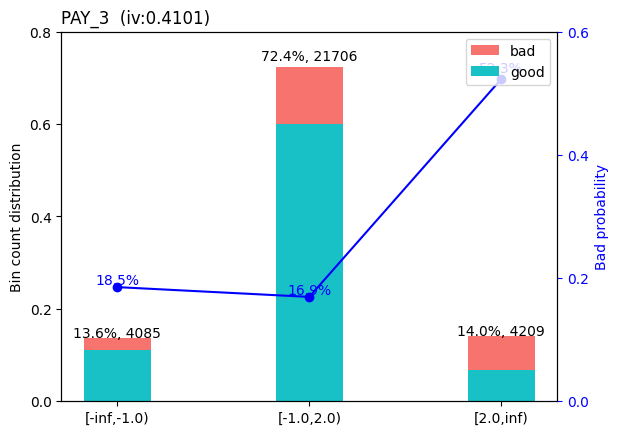

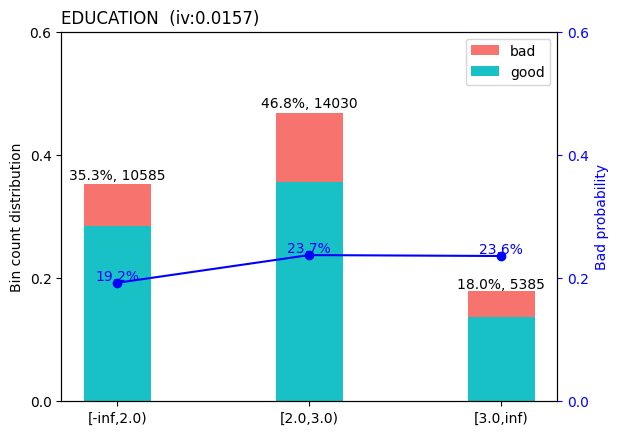

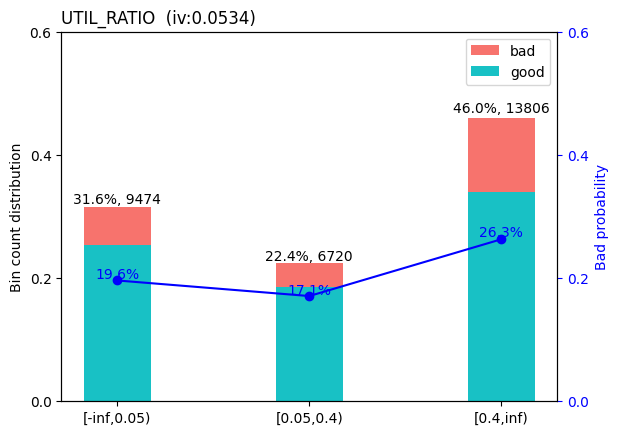

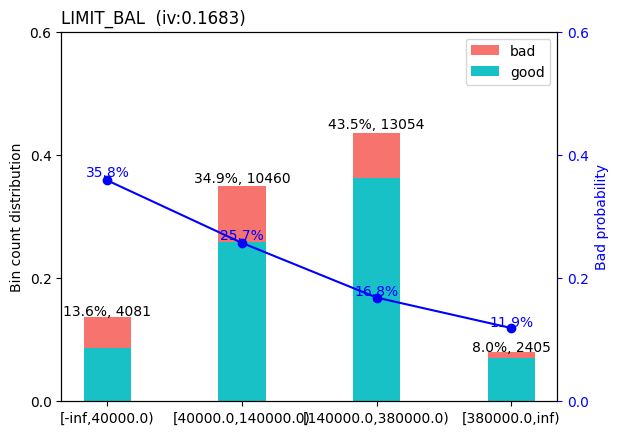

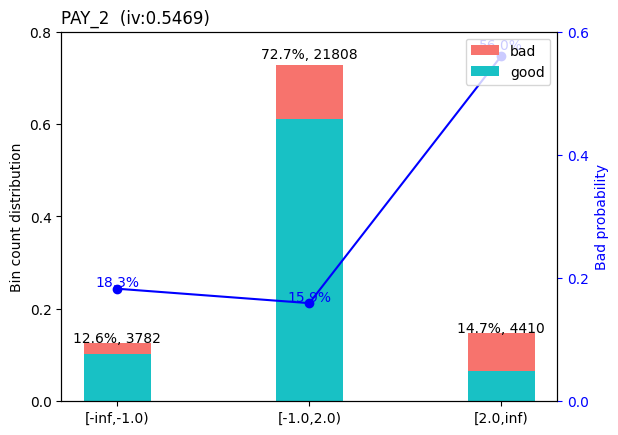

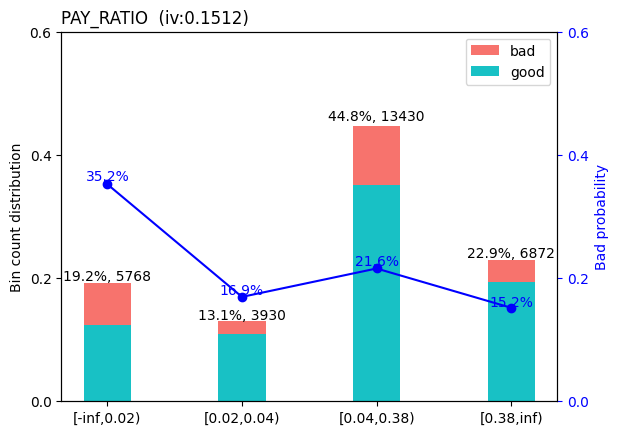

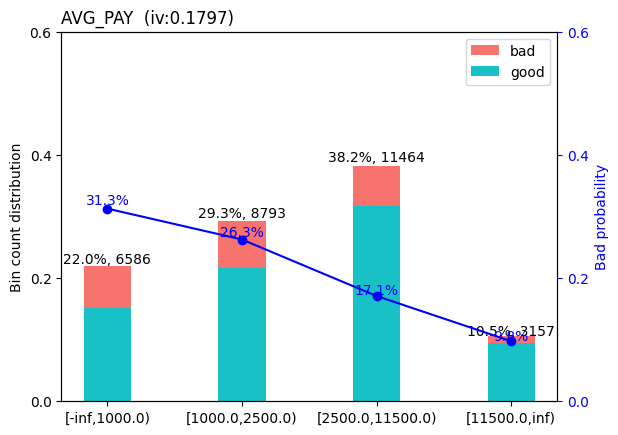

In [16]:
import scorecardpy as sc

# WoE binning and IV calculation
bins = sc.woebin(df[features + ['DEFAULT']], y='DEFAULT')

# IV summary
iv_summary = sc.woebin_plot(bins)

# Print IV values
iv_values = {var: bins[var]['total_iv'].values[0] for var in features}
iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values('IV', ascending=False).reset_index(drop=True)
print(iv_df)

In [17]:
# Select features with IV >= 0.02
selected_features = iv_df[iv_df['IV'] >= 0.02]['Feature'].tolist()
print("Selected features:", selected_features)
print(f"Number of features: {len(selected_features)}")

Selected features: ['PAY_0', 'MAX_DELAY', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'AVG_PAY', 'LIMIT_BAL', 'PAY_RATIO', 'UTIL_RATIO', 'AGE']
Number of features: 12


In [18]:
# Apply WoE transformation
train_woe = sc.woebin_ply(X_train.join(y_train), bins)
test_woe = sc.woebin_ply(X_test.join(y_test), bins)

# Keep only selected features + target
selected_woe = [f + '_woe' for f in selected_features]

X_train_woe = train_woe[selected_woe]
X_test_woe = test_woe[selected_woe]
y_train_woe = train_woe['DEFAULT']
y_test_woe = test_woe['DEFAULT']

print(X_train_woe.shape)
print(X_train_woe.head())

[INFO] converting into woe values ...
[INFO] converting into woe values ...
(24000, 12)
       PAY_0_woe  MAX_DELAY_woe  PAY_2_woe  PAY_3_woe  PAY_4_woe  PAY_5_woe  \
22788   2.084775       1.110445   1.501138    1.35046   1.400233  -0.244304   
29006   0.593072       0.159285  -0.404764   -0.33087  -0.175145  -0.147246   
16950   0.593072       1.110445   1.501138   -0.33087  -0.277851  -0.244304   
22280  -0.659061      -0.761458  -0.404764   -0.33087  -0.277851  -0.244304   
11346   0.593072       0.159285  -0.239423   -0.33087  -0.277851  -0.244304   

       PAY_6_woe  AVG_PAY_woe  LIMIT_BAL_woe  PAY_RATIO_woe  UTIL_RATIO_woe  \
22788  -0.233450    -0.320697      -0.338483      -0.033031        0.227888   
29006  -0.125056     0.471554      -0.338483      -0.462057       -0.152064   
16950  -0.233450     0.471554       0.676765       0.649692        0.227888   
22280  -0.233450    -0.320697      -0.338483      -0.033031        0.227888   
11346  -0.125056     0.471554      -0.3384

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# Build logistic regression
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_woe, y_train_woe)

# Evaluate on test set
y_pred_proba = lr.predict_proba(X_test_woe)[:, 1]
y_pred = lr.predict(X_test_woe)

print(f"AUC-ROC: {roc_auc_score(y_test_woe, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_woe, y_pred))

AUC-ROC: 0.7604

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.46      0.59      0.52      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.76      0.77      6000



In [20]:
# Build scorecard
card = sc.scorecard(bins, lr, selected_features,
                    points0=600, odds0=1/19, pdo=50)

# Apply scorecard to get scores
train_score = sc.scorecard_ply(X_train, card, print_step=0)
test_score = sc.scorecard_ply(X_test, card, print_step=0)

# Add scores to test set for evaluation
X_test_scored = X_test.copy()
X_test_scored['SCORE'] = test_score['score']
X_test_scored['DEFAULT'] = y_test.values

print(X_test_scored[['SCORE', 'DEFAULT']].describe())
print(f"\nAverage score — Non-default: {X_test_scored[X_test_scored['DEFAULT']==0]['SCORE'].mean():.1f}")
print(f"Average score — Default: {X_test_scored[X_test_scored['DEFAULT']==1]['SCORE'].mean():.1f}")

/usr/local/lib/python3.12/dist-packages/scorecardpy/scorecard.py:353: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_score.loc[:,'score'] = card_basepoints + dat_score.sum(axis=1)


             SCORE      DEFAULT
count  6000.000000  6000.000000
mean    402.966000     0.221167
std      76.105739     0.415067
min     163.000000     0.000000
25%     369.000000     0.000000
50%     425.000000     0.000000
75%     455.000000     0.000000
max     517.000000     1.000000

Average score — Non-default: 420.7
Average score — Default: 340.6


/usr/local/lib/python3.12/dist-packages/scorecardpy/scorecard.py:353: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_score.loc[:,'score'] = card_basepoints + dat_score.sum(axis=1)


In [21]:
# Assign risk bands
def risk_band(score):
    if score >= 450:
        return 'Low Risk'
    elif score >= 380:
        return 'Medium Risk'
    else:
        return 'High Risk'

X_test_scored['RISK_BAND'] = X_test_scored['SCORE'].apply(risk_band)

# Risk band distribution
print(X_test_scored['RISK_BAND'].value_counts())
print("\nDefault rate by risk band:")
print(X_test_scored.groupby('RISK_BAND')['DEFAULT'].mean().sort_values(ascending=False))

# Save scored portfolio to outputs
X_test_scored.to_csv('/content/drive/MyDrive/Credit_Risk_Framework/Outputs/scored_portfolio.csv', index=False)
print("\nScored portfolio saved.")

RISK_BAND
Medium Risk    2541
Low Risk       1839
High Risk      1620
Name: count, dtype: int64

Default rate by risk band:
RISK_BAND
High Risk      0.470988
Medium Risk    0.164896
Low Risk       0.078847
Name: DEFAULT, dtype: float64

Scored portfolio saved.
